# Phase 2 — Stochastic Radius and Full Complex Brownian Motion

This notebook numerically checks the Phase 2 derivations:

1. complex self-quadratic variation versus Euclidean energy;
2. the Rice law and second moment of the stochastic radius;
3. Cartesian/polar reconstruction and the random angular clock;
4. the Bessel radial drift;
5. stochastic-logarithm convergence;
6. anisotropy as a counterexample to the correction-free formula.

All experiments use deterministic seeds. Numerical evidence supports
the proofs in the accompanying Markdown files; it does not replace
them.

In [1]:
import os
import platform
import sys

import matplotlib
import matplotlib.pyplot as plt
import nbformat
import numpy as np
import scipy
from scipy import stats

BASE_SEED = 20260723
np.set_printoptions(precision=6, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")

print("Environment:", os.environ.get("CONDA_DEFAULT_ENV", "unknown"))
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)
print("nbformat:", nbformat.__version__)

Environment: base
Python: 3.13.9
Platform: Linux-7.1.4-1-cachyos-x86_64-with-glibc2.43
NumPy: 2.3.5
SciPy: 1.16.3
Matplotlib: 3.10.6
nbformat: 5.10.4


## 1. Two complex quadratic variations

Under the normalization

\[
\Delta Z=\sigma\sqrt h\,(\xi+i\eta),
\]

isotropic planar Brownian motion satisfies

\[
[Z,Z]_T=0,\qquad [Z,\overline Z]_T=2\sigma^2T.
\]

On a finite uniform grid,

\[
\operatorname{Var}\!\left(\operatorname{Re}\sum(\Delta Z)^2\right)
=
\operatorname{Var}\!\left(\operatorname{Im}\sum(\Delta Z)^2\right)
=\frac{4\sigma^4T^2}{N},
\]

while

\[
\mathbb E\sum|\Delta Z|^2=2\sigma^2T,\qquad
\operatorname{Var}\sum|\Delta Z|^2
=\frac{4\sigma^4T^2}{N}.
\]

 N     paths   mean Re self   mean Im self   mean energy   var(Re)/theory  var(E)/theory
  64    30000   0.000955       0.000671       0.979869        0.9928           0.9875
 256    20000  -0.000096       0.000065       0.979682        1.0111           0.9876
1024    10000   0.000211      -0.000377       0.979403        1.0085           0.9868
4096     5000   0.000331      -0.000348       0.979940        0.9779           1.0071

Log-log slope of self-QV RMS versus N: -0.5010 (theory -0.5)


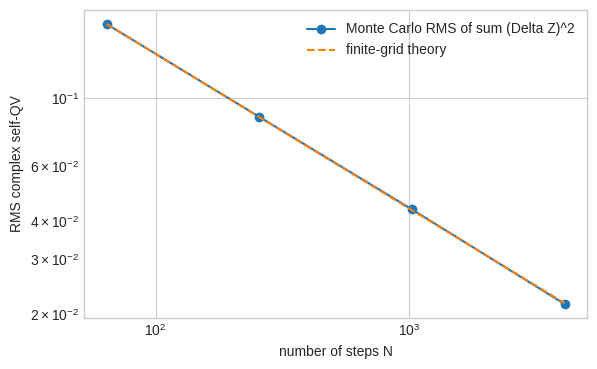

In [2]:
def complex_qv_experiment(N, paths, seed, sigma=0.7, T=1.0, chunk=400):
    rng = np.random.default_rng(seed)
    h = T / N
    q_self = np.empty(paths, dtype=np.complex128)
    q_energy = np.empty(paths)
    offset = 0
    while offset < paths:
        m = min(chunk, paths - offset)
        dW = rng.normal(scale=np.sqrt(h), size=(m, N, 2))
        dZ = sigma * (dW[:, :, 0] + 1j * dW[:, :, 1])
        q_self[offset:offset + m] = np.sum(dZ * dZ, axis=1)
        q_energy[offset:offset + m] = np.sum(np.abs(dZ) ** 2, axis=1)
        offset += m

    theory_var = 4 * sigma**4 * T**2 / N
    return {
        "N": N,
        "paths": paths,
        "self_re_mean": q_self.real.mean(),
        "self_im_mean": q_self.imag.mean(),
        "self_re_var": q_self.real.var(ddof=1),
        "self_im_var": q_self.imag.var(ddof=1),
        "energy_mean": q_energy.mean(),
        "energy_var": q_energy.var(ddof=1),
        "theory_self_mean": 0.0,
        "theory_energy_mean": 2 * sigma**2 * T,
        "theory_var": theory_var,
        "self_rms": np.sqrt(np.mean(np.abs(q_self) ** 2)),
        "theory_self_rms": np.sqrt(2 * theory_var),
    }


qv_specs = [(64, 30000), (256, 20000), (1024, 10000), (4096, 5000)]
qv_results = [
    complex_qv_experiment(N, paths, BASE_SEED + N)
    for N, paths in qv_specs
]

print(
    " N     paths   mean Re self   mean Im self   "
    "mean energy   var(Re)/theory  var(E)/theory"
)
for r in qv_results:
    print(
        f"{r['N']:4d}  {r['paths']:7d}  "
        f"{r['self_re_mean']: .6f}      {r['self_im_mean']: .6f}      "
        f"{r['energy_mean']: .6f}       "
        f"{r['self_re_var']/r['theory_var']: .4f}          "
        f"{r['energy_var']/r['theory_var']: .4f}"
    )

for r in qv_results:
    se_zero = np.sqrt(r["theory_var"] / r["paths"])
    se_energy = np.sqrt(r["theory_var"] / r["paths"])
    assert abs(r["self_re_mean"]) < 4.5 * se_zero
    assert abs(r["self_im_mean"]) < 4.5 * se_zero
    assert abs(r["energy_mean"] - r["theory_energy_mean"]) < 4.5 * se_energy
    assert abs(r["self_re_var"] / r["theory_var"] - 1) < 0.12
    assert abs(r["self_im_var"] / r["theory_var"] - 1) < 0.12
    assert abs(r["energy_var"] / r["theory_var"] - 1) < 0.12

Ns = np.array([r["N"] for r in qv_results])
rms = np.array([r["self_rms"] for r in qv_results])
theory_rms = np.array([r["theory_self_rms"] for r in qv_results])
slope = np.polyfit(np.log(Ns), np.log(rms), 1)[0]
print(f"\nLog-log slope of self-QV RMS versus N: {slope:.4f} (theory -0.5)")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.loglog(Ns, rms, "o-", label="Monte Carlo RMS of sum (Delta Z)^2")
ax.loglog(Ns, theory_rms, "--", label="finite-grid theory")
ax.set_xlabel("number of steps N")
ax.set_ylabel("RMS complex self-QV")
ax.legend()
plt.show()

The complex-bilinear square converges to zero even while the Euclidean
energy converges to a positive limit. This is the numerical signature
of conformal cancellation, not an absence of planar randomness.

## 2. The stochastic radius and its Rice distribution

If

\[
Z_T=Z_0+\sigma(W_T^1+iW_T^2),
\]

then \(R_T=|Z_T|\) has a Rice distribution with

\[
b=\frac{|Z_0|}{\sigma\sqrt T},
\qquad \text{scale}=\sigma\sqrt T.
\]

Also,

\[
\mathbb E R_T^2=|Z_0|^2+2\sigma^2T.
\]

Rice parameters: b=1.512603, scale=0.712039
R mean: empirical=1.341791, theory=1.341644, z=0.093
R variance: empirical=0.376195, theory=0.373992
E[R^2]: empirical=2.176596, theory=2.174000, z=0.544
KS statistic=0.001589, 1.36/sqrt(M)=0.003512, p=0.8428


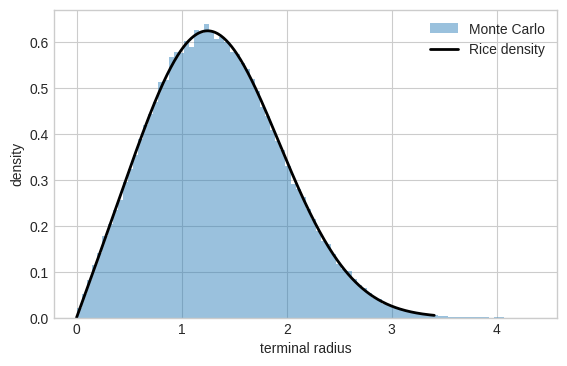

In [3]:
rng = np.random.default_rng(BASE_SEED + 100)
radius_paths = 150_000
z0_radius = 1.0 + 0.4j
sigma_radius = 0.65
T_radius = 1.2
terminal_noise = rng.normal(size=(radius_paths, 2))
ZT = z0_radius + sigma_radius * np.sqrt(T_radius) * (
    terminal_noise[:, 0] + 1j * terminal_noise[:, 1]
)
RT = np.abs(ZT)

scale = sigma_radius * np.sqrt(T_radius)
rice_b = abs(z0_radius) / scale
rice_mean, rice_var = stats.rice.stats(rice_b, scale=scale, moments="mv")
empirical_mean = RT.mean()
empirical_var = RT.var(ddof=1)
mean_se = RT.std(ddof=1) / np.sqrt(radius_paths)

R2 = RT**2
theory_R2 = abs(z0_radius) ** 2 + 2 * sigma_radius**2 * T_radius
R2_se = R2.std(ddof=1) / np.sqrt(radius_paths)
ks = stats.kstest(RT, "rice", args=(rice_b, 0, scale))
ks_reference = 1.36 / np.sqrt(radius_paths)

print(f"Rice parameters: b={rice_b:.6f}, scale={scale:.6f}")
print(
    f"R mean: empirical={empirical_mean:.6f}, theory={rice_mean:.6f}, "
    f"z={(empirical_mean-rice_mean)/mean_se:.3f}"
)
print(
    f"R variance: empirical={empirical_var:.6f}, theory={rice_var:.6f}"
)
print(
    f"E[R^2]: empirical={R2.mean():.6f}, theory={theory_R2:.6f}, "
    f"z={(R2.mean()-theory_R2)/R2_se:.3f}"
)
print(
    f"KS statistic={ks.statistic:.6f}, "
    f"1.36/sqrt(M)={ks_reference:.6f}, p={ks.pvalue:.4f}"
)

assert abs(empirical_mean - rice_mean) < 4.5 * mean_se
assert abs(R2.mean() - theory_R2) < 4.5 * R2_se
assert ks.statistic < 1.8 / np.sqrt(radius_paths)

x = np.linspace(0, np.quantile(RT, 0.999), 400)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(RT, bins=90, density=True, alpha=0.45, label="Monte Carlo")
ax.plot(x, stats.rice.pdf(x, rice_b, scale=scale), "k-", lw=2, label="Rice density")
ax.set_xlabel("terminal radius")
ax.set_ylabel("density")
ax.legend()
plt.show()

## 3. Cartesian/polar reconstruction and the random clock

For the isotropic process,

\[
d\log R_t=\frac{\sigma}{R_t}dB_t^R,\qquad
d\Theta_t=\frac{\sigma}{R_t}dB_t^\Theta.
\]

Both local martingales have quadratic variation

\[
H_t=\int_0^t\frac{\sigma^2}{R_s^2}\,ds,
\]

and their cross-variation is zero.

Minimum radius on displayed path: 1.609401
Maximum Cartesian-polar reconstruction error: 4.578e-16
Adapted Brownian grid QVs [BR, BTheta, cross] = [ 0.986288  1.015184 -0.008828]


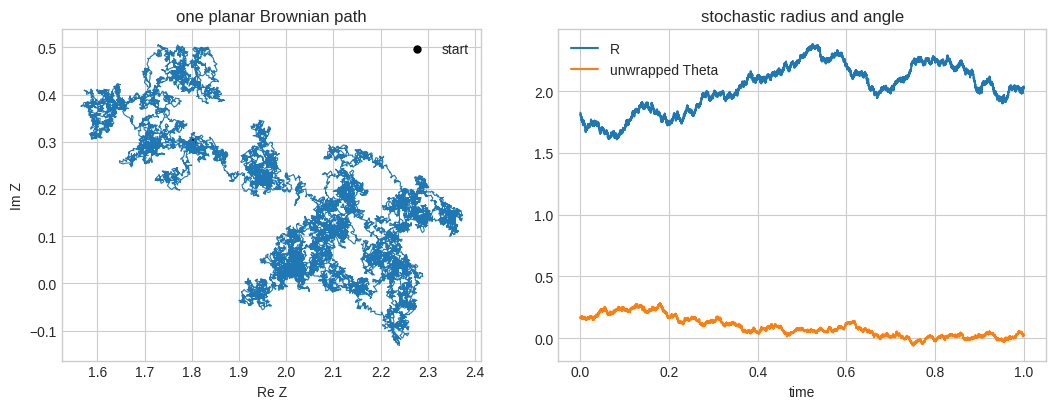

In [4]:
rng = np.random.default_rng(BASE_SEED + 200)
path_N = 20_000
path_T = 1.0
path_sigma = 0.45
path_z0 = 1.8 + 0.3j
path_h = path_T / path_N
dW = rng.normal(scale=np.sqrt(path_h), size=(path_N, 2))
dZ = path_sigma * (dW[:, 0] + 1j * dW[:, 1])
Z_path = np.empty(path_N + 1, dtype=np.complex128)
Z_path[0] = path_z0
Z_path[1:] = path_z0 + np.cumsum(dZ)
R_path = np.abs(Z_path)
Theta_path = np.unwrap(np.angle(Z_path))
Z_reconstructed = R_path * np.exp(1j * Theta_path)
reconstruction_error = np.max(np.abs(Z_reconstructed - Z_path))

theta_left = Theta_path[:-1]
dBR = np.cos(theta_left) * dW[:, 0] + np.sin(theta_left) * dW[:, 1]
dBTheta = -np.sin(theta_left) * dW[:, 0] + np.cos(theta_left) * dW[:, 1]
adapted_qv = np.array(
    [np.sum(dBR**2), np.sum(dBTheta**2), np.sum(dBR * dBTheta)]
)

print(f"Minimum radius on displayed path: {R_path.min():.6f}")
print(f"Maximum Cartesian-polar reconstruction error: {reconstruction_error:.3e}")
print(
    "Adapted Brownian grid QVs "
    f"[BR, BTheta, cross] = {adapted_qv}"
)
assert reconstruction_error < 2e-14

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(Z_path.real, Z_path.imag, lw=0.8)
axes[0].scatter([path_z0.real], [path_z0.imag], c="black", s=25, label="start")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlabel("Re Z")
axes[0].set_ylabel("Im Z")
axes[0].set_title("one planar Brownian path")
axes[0].legend()
times = np.linspace(0, path_T, path_N + 1)
axes[1].plot(times, R_path, label="R")
axes[1].plot(times, Theta_path, label="unwrapped Theta")
axes[1].set_xlabel("time")
axes[1].set_title("stochastic radius and angle")
axes[1].legend()
plt.tight_layout()
plt.show()

In [5]:
def polar_clock_experiment(N, paths, seed, z0=1.5 + 0.3j,
                           sigma=0.4, T=1.0, epsilon=0.35):
    rng = np.random.default_rng(seed)
    h = T / N
    z = np.full(paths, z0, dtype=np.complex128)
    active = np.ones(paths, dtype=bool)
    qv_theta = np.zeros(paths)
    qv_logr = np.zeros(paths)
    cross = np.zeros(paths)
    clock = np.zeros(paths)

    for _ in range(N):
        d = sigma * np.sqrt(h) * (
            rng.standard_normal(paths) + 1j * rng.standard_normal(paths)
        )
        z_new = z + d
        valid = active & (np.abs(z_new) > epsilon)
        idx = np.flatnonzero(valid)
        if idx.size:
            ratio = z_new[idx] / z[idx]
            dtheta = np.angle(ratio)
            dlogr = np.log(np.abs(ratio))
            qv_theta[idx] += dtheta**2
            qv_logr[idx] += dlogr**2
            cross[idx] += dtheta * dlogr
            clock[idx] += sigma**2 * h / np.abs(z[idx])**2
        active &= np.abs(z_new) > epsilon
        z = z_new

    kept = active & (clock > 0)
    theta_ratio = qv_theta[kept] / clock[kept]
    logr_ratio = qv_logr[kept] / clock[kept]
    cross_ratio = cross[kept] / clock[kept]
    return {
        "N": N,
        "paths": paths,
        "kept": kept.sum(),
        "stopped_fraction": 1 - kept.mean(),
        "theta_ratio_mean": theta_ratio.mean(),
        "theta_ratio_se": theta_ratio.std(ddof=1) / np.sqrt(kept.sum()),
        "logr_ratio_mean": logr_ratio.mean(),
        "logr_ratio_se": logr_ratio.std(ddof=1) / np.sqrt(kept.sum()),
        "cross_ratio_mean": cross_ratio.mean(),
        "cross_ratio_se": cross_ratio.std(ddof=1) / np.sqrt(kept.sum()),
        "mean_clock": clock[kept].mean(),
    }


clock_specs = [(250, 12000), (1000, 8000), (4000, 4000)]
clock_results = [
    polar_clock_experiment(N, paths, BASE_SEED + 300 + N)
    for N, paths in clock_specs
]

print(
    " N    kept/paths   stop%    mean QV(Theta)/H   "
    "mean QV(logR)/H   mean cross/H"
)
for r in clock_results:
    print(
        f"{r['N']:4d}  {r['kept']:5d}/{r['paths']:<5d} "
        f"{100*r['stopped_fraction']:6.3f}   "
        f"{r['theta_ratio_mean']: .6f}          "
        f"{r['logr_ratio_mean']: .6f}         "
        f"{r['cross_ratio_mean']: .6f}"
    )

finest_clock = clock_results[-1]
assert abs(finest_clock["theta_ratio_mean"] - 1) < 0.035
assert abs(finest_clock["logr_ratio_mean"] - 1) < 0.035
assert abs(finest_clock["cross_ratio_mean"]) < 0.02

 N    kept/paths   stop%    mean QV(Theta)/H   mean QV(logR)/H   mean cross/H
 250  11987/12000  0.108    0.998829           0.999173         -0.000476
1000   7989/8000   0.138    0.998888           1.000073         -0.000222
4000   3992/4000   0.200    0.999991           0.999818         -0.000467


## 4. Conditional verification of the Bessel radial drift

The radial SDE predicts

\[
\mathbb E[dR_t\mid R_t,\Theta_t]
=\frac{\sigma^2}{2R_t}dt.
\]

We bin the current radius and compare observed radial increments with
the pathwise predicted drift. The Monte Carlo standard error is
computed from the residual increments in each bin.

In [6]:
def radial_drift_bins(seed, paths=18_000, N=800, T=0.6,
                      z0=1.0 + 0j, sigma=0.5, epsilon=0.35):
    rng = np.random.default_rng(seed)
    h = T / N
    edges = np.array([0.4, 0.65, 0.9, 1.15, 1.4, 1.7, 2.1])
    nbins = len(edges) - 1
    count = np.zeros(nbins, dtype=np.int64)
    sum_obs = np.zeros(nbins)
    sum_pred = np.zeros(nbins)
    sum_res = np.zeros(nbins)
    sum_res2 = np.zeros(nbins)
    sum_r = np.zeros(nbins)
    sum_theta2 = np.zeros(nbins)
    sum_theta_pred = np.zeros(nbins)
    sum_theta_res = np.zeros(nbins)
    sum_theta_res2 = np.zeros(nbins)
    z = np.full(paths, z0, dtype=np.complex128)
    active = np.ones(paths, dtype=bool)

    for _ in range(N):
        r = np.abs(z)
        d = sigma * np.sqrt(h) * (
            rng.standard_normal(paths) + 1j * rng.standard_normal(paths)
        )
        z_new = z + d
        r_new = np.abs(z_new)
        valid = active & (r > epsilon) & (r_new > epsilon)
        bins = np.digitize(r, edges) - 1
        valid &= (bins >= 0) & (bins < nbins)
        idx = np.flatnonzero(valid)
        if idx.size:
            b = bins[idx]
            dr = r_new[idx] - r[idx]
            pred = sigma**2 * h / (2 * r[idx])
            res = dr - pred
            dtheta = np.angle(z_new[idx] / z[idx])
            theta_pred = sigma**2 * h / r[idx]**2
            theta_res = dtheta**2 - theta_pred
            count += np.bincount(b, minlength=nbins)
            sum_obs += np.bincount(b, weights=dr, minlength=nbins)
            sum_pred += np.bincount(b, weights=pred, minlength=nbins)
            sum_res += np.bincount(b, weights=res, minlength=nbins)
            sum_res2 += np.bincount(b, weights=res**2, minlength=nbins)
            sum_r += np.bincount(b, weights=r[idx], minlength=nbins)
            sum_theta2 += np.bincount(b, weights=dtheta**2, minlength=nbins)
            sum_theta_pred += np.bincount(b, weights=theta_pred, minlength=nbins)
            sum_theta_res += np.bincount(b, weights=theta_res, minlength=nbins)
            sum_theta_res2 += np.bincount(
                b, weights=theta_res**2, minlength=nbins
            )
        active &= r_new > epsilon
        z = z_new

    observed_rate = sum_obs / (count * h)
    predicted_rate = sum_pred / (count * h)
    residual_var = sum_res2 / count - (sum_res / count) ** 2
    se_rate = np.sqrt(residual_var / count) / h
    zscore = (observed_rate - predicted_rate) / se_rate
    theta_rate = sum_theta2 / (count * h)
    theta_rate_pred = sum_theta_pred / (count * h)
    theta_res_var = (
        sum_theta_res2 / count - (sum_theta_res / count) ** 2
    )
    theta_se = np.sqrt(theta_res_var / count) / h
    theta_z = (theta_rate - theta_rate_pred) / theta_se
    return (
        edges,
        count,
        sum_r / count,
        observed_rate,
        predicted_rate,
        se_rate,
        zscore,
        theta_rate,
        theta_rate_pred,
        theta_se,
        theta_z,
    )


drift = radial_drift_bins(BASE_SEED + 400)
(
    edges,
    counts,
    mean_r,
    observed_rate,
    predicted_rate,
    se_rate,
    drift_z,
    theta_rate,
    theta_rate_pred,
    theta_se,
    theta_z,
) = drift
print("radius bin    count      mean R   observed drift   predicted drift   z")
for j in range(len(counts)):
    print(
        f"[{edges[j]:.2f},{edges[j+1]:.2f}) "
        f"{counts[j]:9d}  {mean_r[j]:.5f}   "
        f"{observed_rate[j]: .6f}       {predicted_rate[j]: .6f}      "
        f"{drift_z[j]: .3f}"
    )

assert np.all(np.abs(drift_z[counts > 100_000]) < 4.5)

print(
    "\nradius bin    observed angular variance rate   "
    "predicted sigma^2/R^2   z"
)
for j in range(len(counts)):
    print(
        f"[{edges[j]:.2f},{edges[j+1]:.2f}) "
        f"{theta_rate[j]: .6f}                         "
        f"{theta_rate_pred[j]: .6f}             "
        f"{theta_z[j]: .3f}"
    )

# Both observed and predicted winding rates must fall sharply as R grows.
assert np.all(np.diff(theta_rate_pred) < 0)
assert theta_rate[0] > 5 * theta_rate[-1]

radius bin    count      mean R   observed drift   predicted drift   z
[0.40,0.65)    699715  0.56349    0.249659        0.225011       1.131
[0.65,0.90)   3004959  0.79957    0.166876        0.157564       0.884
[0.90,1.15)   6116976  1.02230    0.123414        0.122822       0.080
[1.15,1.40)   3058084  1.25474    0.096944        0.099931      -0.286
[1.40,1.70)   1087174  1.51205    0.088959        0.082901       0.346
[1.70,2.10)    188846  1.81369    0.030330        0.069099      -0.924

radius bin    observed angular variance rate   predicted sigma^2/R^2   z
[0.40,0.65)  0.822970                          0.822799              0.119
[0.65,0.90)  0.399457                          0.400483             -3.093
[0.90,1.15)  0.242540                          0.242449              0.655
[1.15,1.40)  0.160382                          0.160266              0.889
[1.40,1.70)  0.110122                          0.110259             -0.913
[1.70,2.10)  0.076857                          0.07658

## 5. Stochastic-logarithm reconstruction

The exact finite-step logarithm is

\[
\operatorname{Log}_{\rm cont}\left(1+\frac{\Delta Z_n}{Z_n}\right).
\]

Its second-order approximation is

\[
\frac{\Delta Z_n}{Z_n}
-\frac12\left(\frac{\Delta Z_n}{Z_n}\right)^2.
\]

For isotropic noise, the continuous complex self-quadratic variation
vanishes. The first-order Itô sum therefore converges, while the
realized second-order finite-grid correction improves pathwise
accuracy at finite \(h\).

In [7]:
def logarithm_reconstruction(N, paths, seed, sigma_x, sigma_y,
                             T=0.8, z0=2.0 + 0.4j, epsilon=0.6):
    rng = np.random.default_rng(seed)
    h = T / N
    z = np.full(paths, z0, dtype=np.complex128)
    active = np.ones(paths, dtype=bool)
    L_first = np.zeros(paths, dtype=np.complex128)
    L_taylor2 = np.zeros(paths, dtype=np.complex128)
    L_ito = np.zeros(paths, dtype=np.complex128)
    L_exact = np.zeros(paths, dtype=np.complex128)
    self_qv = np.zeros(paths, dtype=np.complex128)
    q_rate = sigma_x**2 - sigma_y**2

    for _ in range(N):
        d = np.sqrt(h) * (
            sigma_x * rng.standard_normal(paths)
            + 1j * sigma_y * rng.standard_normal(paths)
        )
        z_new = z + d
        valid = active & (np.abs(z_new) > epsilon)
        idx = np.flatnonzero(valid)
        if idx.size:
            q = d[idx] / z[idx]
            exact_step = np.log(np.abs(z_new[idx] / z[idx])) + 1j * np.angle(
                z_new[idx] / z[idx]
            )
            L_first[idx] += q
            L_taylor2[idx] += q - 0.5 * q**2
            L_ito[idx] += q - 0.5 * q_rate * h / z[idx] ** 2
            L_exact[idx] += exact_step
            self_qv[idx] += d[idx] ** 2
        active &= np.abs(z_new) > epsilon
        z = z_new

    idx = np.flatnonzero(active)
    target = z[idx] / z0
    errors = {}
    for name, L in [
        ("first", L_first),
        ("taylor2", L_taylor2),
        ("ito", L_ito),
        ("exact", L_exact),
    ]:
        e = np.abs(np.exp(L[idx]) - target)
        errors[name] = (e.mean(), e.std(ddof=1) / np.sqrt(idx.size))

    return {
        "N": N,
        "h": h,
        "paths": paths,
        "kept": idx.size,
        "stopped_fraction": 1 - idx.size / paths,
        "errors": errors,
        "self_qv_mean": self_qv[idx].mean(),
        "self_qv_se_re": self_qv[idx].real.std(ddof=1) / np.sqrt(idx.size),
        "self_qv_se_im": self_qv[idx].imag.std(ddof=1) / np.sqrt(idx.size),
        "self_qv_theory": q_rate * T,
    }


iso_specs = [(64, 18000), (256, 12000), (1024, 6000), (4096, 3000)]
iso_results = [
    logarithm_reconstruction(
        N, paths, BASE_SEED + 500 + N, sigma_x=0.45, sigma_y=0.45
    )
    for N, paths in iso_specs
]

print(
    "Isotropic case\n"
    " N    kept/paths   stop%    mean error first   "
    "mean error Taylor-2   exact-log error"
)
for r in iso_results:
    print(
        f"{r['N']:4d}  {r['kept']:5d}/{r['paths']:<5d} "
        f"{100*r['stopped_fraction']:6.3f}   "
        f"{r['errors']['first'][0]:.7f}          "
        f"{r['errors']['taylor2'][0]:.7f}           "
        f"{r['errors']['exact'][0]:.3e}"
    )

hs_iso = np.array([r["h"] for r in iso_results])
e_first_iso = np.array([r["errors"]["first"][0] for r in iso_results])
e_t2_iso = np.array([r["errors"]["taylor2"][0] for r in iso_results])
slope_first_iso = np.polyfit(np.log(hs_iso), np.log(e_first_iso), 1)[0]
slope_t2_iso = np.polyfit(np.log(hs_iso), np.log(e_t2_iso), 1)[0]
print(
    f"Isotropic slopes vs h: first={slope_first_iso:.4f}, "
    f"Taylor-2={slope_t2_iso:.4f}"
)

assert iso_results[-1]["errors"]["taylor2"][0] < iso_results[-1]["errors"]["first"][0]
assert iso_results[-1]["errors"]["exact"][0] < 2e-13
assert 0.35 < slope_first_iso < 0.70
assert 0.70 < slope_t2_iso < 1.25

Isotropic case
 N    kept/paths   stop%    mean error first   mean error Taylor-2   exact-log error
  64  17998/18000  0.011   0.0062879          0.0002620           8.936e-16
 256  12000/12000  0.000   0.0031901          0.0000669           1.760e-15
1024   5999/6000   0.017   0.0015850          0.0000165           3.626e-15
4096   3000/3000   0.000   0.0007851          0.0000042           9.029e-15
Isotropic slopes vs h: first=0.5007, Taylor-2=0.9949


## 6. Anisotropy: the correction is now essential

For

\[
dZ=\sigma_xdW^1+i\sigma_ydW^2,
\]

\[
d[Z,Z]=(\sigma_x^2-\sigma_y^2)dt.
\]

The correct stochastic logarithm is

\[
d\log Z
=\frac{dZ}{Z}
-\frac{\sigma_x^2-\sigma_y^2}{2Z^2}dt.
\]

We compare the uncorrected first-order exponential, the discrete
Taylor correction, and the continuous Itô compensator.

Anisotropic case
 N    error uncorrected   error Taylor-2   error Ito-corrected   mean self-QV (real)
  64  0.0367731             0.0004684          0.0076642             0.287687
 256  0.0366605             0.0001181          0.0038425             0.288069
1024  0.0365787             0.0000303          0.0019198             0.288122
4096  0.0365905             0.0000077          0.0009424             0.288231
Theoretical [Z,Z]_T=0.288000; finest-grid mean=0.288231; z=1.707
Anisotropic corrected slopes vs h: Taylor-2=0.9864, Ito=0.5036


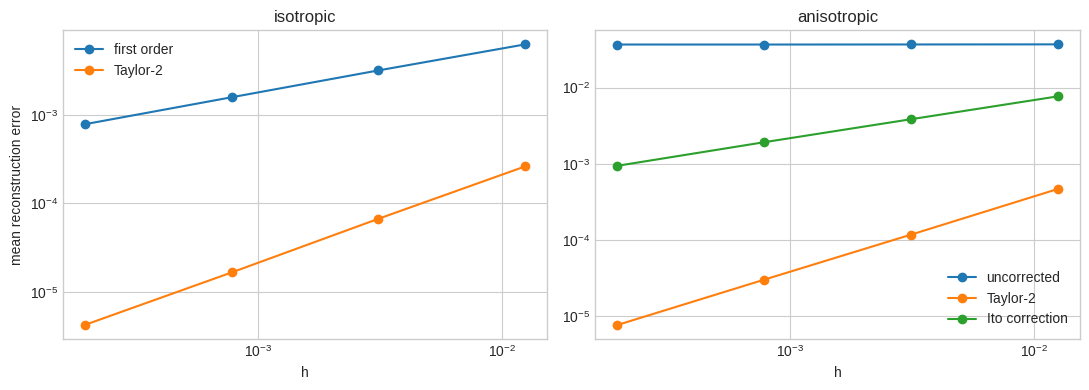

In [8]:
aniso_specs = [(64, 18000), (256, 12000), (1024, 6000), (4096, 3000)]
sigma_x_aniso = 0.65
sigma_y_aniso = 0.25
aniso_results = [
    logarithm_reconstruction(
        N,
        paths,
        BASE_SEED + 600 + N,
        sigma_x=sigma_x_aniso,
        sigma_y=sigma_y_aniso,
    )
    for N, paths in aniso_specs
]

q_theory = (sigma_x_aniso**2 - sigma_y_aniso**2) * 0.8
print(
    "Anisotropic case\n"
    " N    error uncorrected   error Taylor-2   error Ito-corrected   "
    "mean self-QV (real)"
)
for r in aniso_results:
    print(
        f"{r['N']:4d}  {r['errors']['first'][0]:.7f}             "
        f"{r['errors']['taylor2'][0]:.7f}          "
        f"{r['errors']['ito'][0]:.7f}             "
        f"{r['self_qv_mean'].real:.6f}"
    )

finest_aniso = aniso_results[-1]
qv_z = (
    finest_aniso["self_qv_mean"].real - q_theory
) / finest_aniso["self_qv_se_re"]
print(
    f"Theoretical [Z,Z]_T={q_theory:.6f}; finest-grid mean="
    f"{finest_aniso['self_qv_mean'].real:.6f}; z={qv_z:.3f}"
)

hs_aniso = np.array([r["h"] for r in aniso_results])
e_first_aniso = np.array([r["errors"]["first"][0] for r in aniso_results])
e_t2_aniso = np.array([r["errors"]["taylor2"][0] for r in aniso_results])
e_ito_aniso = np.array([r["errors"]["ito"][0] for r in aniso_results])
slope_t2_aniso = np.polyfit(np.log(hs_aniso), np.log(e_t2_aniso), 1)[0]
slope_ito_aniso = np.polyfit(np.log(hs_aniso), np.log(e_ito_aniso), 1)[0]
print(
    f"Anisotropic corrected slopes vs h: Taylor-2={slope_t2_aniso:.4f}, "
    f"Ito={slope_ito_aniso:.4f}"
)

assert abs(qv_z) < 4.5
assert finest_aniso["errors"]["taylor2"][0] < 0.3 * finest_aniso["errors"]["first"][0]
assert finest_aniso["errors"]["ito"][0] < 0.45 * finest_aniso["errors"]["first"][0]
assert 0.65 < slope_t2_aniso < 1.25
assert 0.35 < slope_ito_aniso < 0.75

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].loglog(hs_iso, e_first_iso, "o-", label="first order")
axes[0].loglog(hs_iso, e_t2_iso, "o-", label="Taylor-2")
axes[0].set_title("isotropic")
axes[0].set_xlabel("h")
axes[0].set_ylabel("mean reconstruction error")
axes[0].legend()

axes[1].loglog(hs_aniso, e_first_aniso, "o-", label="uncorrected")
axes[1].loglog(hs_aniso, e_t2_aniso, "o-", label="Taylor-2")
axes[1].loglog(hs_aniso, e_ito_aniso, "o-", label="Ito correction")
axes[1].set_title("anisotropic")
axes[1].set_xlabel("h")
axes[1].legend()
plt.tight_layout()
plt.show()

## Conclusions

The experiments verify six distinct claims:

1. isotropic planar Brownian motion has zero complex self-QV but
   positive Euclidean QV;
2. its radius is genuinely stochastic and has the predicted Rice law;
3. Cartesian and polar coordinates reconstruct the same path;
4. log-radius and angle share the random clock
   \(\int\sigma^2/R^2\,dt\);
5. the Bessel drift is visible in conditional radial increments;
6. the correction-free complex exponential is special to isotropic
   noise—anisotropy restores the quadratic-variation correction.